# OVSeg Colab Inference Notebook

이 노트북은 스마트팩토리캡스톤디자인(SFC4001) 신재호 과제로 <br>
`facebookresearch/ov-seg`를 Google Colab에서 **학습 없이 inference만** 실행하기 위한 주피터 노트북입니다.


구성은 다음 순서입니다.

1. GPU 확인
2. Miniconda / `ovseg` 환경 준비
3. OVSeg clone 및 CLIP 설치
4. checkpoint 다운로드
5. 호환성 패치
6. 공식 toy examples 다운로드
7. 공식 toy examples 일괄 inference
8. 결과 시각화
9. 사용자 이미지로 inference

> 참고: 공식 Hugging Face demo의 examples에는 `MaskFormer`와 `Segment_Anything` 예시가 함께 있습니다. 하지만 공식 demo 설명에 따르면 Colab에서는 기본적으로 `MaskFormer` proposal generator만 지원합니다. 따라서 이 노트북은 공식 toy example의 이미지와 class prompt를 모두 포함하되, 실행은 `demo.py` 기반 `MaskFormer` 흐름으로 통일합니다.


## 0. GPU 확인

Colab 메뉴에서 `런타임 → 런타임 유형 변경 → GPU`를 먼저 선택하세요.

In [1]:
!nvidia-smi

Tue May  5 12:10:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Miniconda 설치

이미 설치되어 있으면 건너뜁니다.

In [2]:
%%bash
set -e

if [ ! -d /usr/local/miniconda ]; then
  echo "[setup] Installing Miniconda..."
  wget -q https://repo.anaconda.com/miniconda/Miniconda3-py38_23.3.1-0-Linux-x86_64.sh -O /tmp/miniconda.sh
  bash /tmp/miniconda.sh -b -p /usr/local/miniconda
else
  echo "[setup] Miniconda already exists."
fi

source /usr/local/miniconda/etc/profile.d/conda.sh
conda --version


[setup] Installing Miniconda...
PREFIX=/usr/local/miniconda
Unpacking payload ...

Installing base environment...





Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
conda 23.3.1


## 2. `ovseg` 환경 생성 및 의존성 설치

- 기본값은 **기존 환경을 삭제하지 않고 재사용**합니다.
- 환경이 꼬였을 때만 아래 셀의 `RESET_ENV=0`을 `RESET_ENV=1`로 바꿉니다.
- PyTorch는 conda solver 지연을 피하기 위해 `pip wheel`로 설치합니다.


In [3]:
%%bash
set -e

RESET_ENV=0

source /usr/local/miniconda/etc/profile.d/conda.sh

if [ "$RESET_ENV" = "1" ]; then
  echo "[setup] Removing existing ovseg environment..."
  conda env remove -n ovseg -y || true
fi

if ! conda env list | awk '{print $1}' | grep -qx "ovseg"; then
  echo "[setup] Creating ovseg environment..."
  conda create -n ovseg python=3.8 -y
else
  echo "[setup] ovseg environment already exists."
fi

conda activate ovseg

echo "[setup] Checking whether core packages are already installed..."
if python - <<'PY'
import torch
import torchvision
import detectron2
from PIL import Image
assert torch.__version__.startswith("1.10.1")
assert torchvision.__version__.startswith("0.11.2")
assert hasattr(Image, "LINEAR") or hasattr(Image, "BILINEAR")
print("core packages already available")
PY
then
  echo "[setup] Skipping package installation."
else
  echo "[setup] Installing PyTorch, Detectron2, and OVSeg dependencies..."

  python -m pip install --upgrade pip
  python -m pip install "setuptools==59.5.0" wheel

  python -m pip install \
    torch==1.10.1+cu113 \
    torchvision==0.11.2+cu113 \
    torchaudio==0.10.1+cu113 \
    -f https://download.pytorch.org/whl/cu113/torch_stable.html

  python -m pip install \
    "numpy==1.23.5" \
    "cython==0.29.36" \
    "scipy==1.10.1" \
    "shapely==1.8.5.post1" \
    "timm==0.6.13" \
    "h5py==3.8.0" \
    "wandb==0.15.12" \
    "fire==0.5.0" \
    "opencv-python==4.7.0.72" \
    "pandas==1.5.3" \
    "braceexpand==0.1.7" \
    "torch-ema==0.3" \
    "torchmetrics==0.11.4" \
    "webdataset==0.2.48" \
    "gdown==4.7.1" \
    "ftfy==6.1.1" \
    "regex" \
    "tqdm" \
    "matplotlib" \
    "Pillow==9.5.0"

  python -m pip install detectron2 \
    -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu113/torch1.10/index.html
fi

python - <<'PY'
import torch
import torchvision
import detectron2
from PIL import Image
import PIL

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
print("Pillow:", PIL.__version__)
print("Has Image.LINEAR:", hasattr(Image, "LINEAR"))
print("detectron2 imported successfully")
PY


[setup] Creating ovseg environment...
Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/miniconda/envs/ovseg

  added / updated specs:
    - python=3.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       h06a4308_0         126 KB
    ld_impl_linux-64-2.44      |       h9e0c5a2_3         725 KB
    libffi-3.4.8               |       hc5d346e_2         136 KB
    libgcc-15.2.0              |       h69a1729_7         806 KB
    libgcc-ng-15.2.0           |       h166f726_7          28 KB
    libgomp-15.2.0             |       h4751f2c_7         436 KB
    libstdcxx-15.2.0           |       h39759b7_7         3.7 MB
    libstdcxx-ng-15.2.0        |       hc03a8fd_7          28 KB
    libxcb-1.1



==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.3.2


Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
ModuleNotFoundError: No module named 'torch'
<stdin>:11: DeprecationWarning: LINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use BILINEAR or Resampling.BILINEAR instead.


## 3. OVSeg clone, modified CLIP 설치, 호환성 패치

- GitHub 레포 clone
- `third_party/CLIP` editable install
- `np.int` / `np.int6464` 패치
- Pillow 10.x 환경에서도 동작하도록 Detectron2의 `Image.LINEAR` 방어 패치


In [4]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content

if [ ! -d ov-seg ]; then
  git clone https://github.com/facebookresearch/ov-seg.git
else
  echo "[repo] /content/ov-seg already exists."
fi

cd /content/ov-seg

echo "[repo] Installing modified CLIP..."
cd third_party/CLIP
python -m pip install -Ue .
cd /content/ov-seg

echo "[patch] Applying compatibility patches..."
python - <<'PY'
from pathlib import Path
import re

# 1) OVSeg predictor: deprecated np.int and accidental np.int6464 fix
predictor = Path("open_vocab_seg/utils/predictor.py")
if predictor.exists():
    s = predictor.read_text()
    s = s.replace("np.int6464", "np.int64")
    s = re.sub(r"np\.int(?![0-9])", "np.int64", s)
    predictor.write_text(s)
    print("patched:", predictor)
    for i, line in enumerate(predictor.read_text().splitlines(), start=1):
        if "np.int" in line:
            print(f"  {i}: {line}")
else:
    print("warning: predictor.py not found")

# 2) Detectron2: Pillow 10 removed Image.LINEAR, so use BILINEAR as a safe fallback.
try:
    import detectron2
    d2_transform = Path(detectron2.__file__).parent / "data/transforms/transform.py"
    if d2_transform.exists():
        s = d2_transform.read_text()
        if "Image.LINEAR" in s:
            s = s.replace("Image.LINEAR", "Image.BILINEAR")
            d2_transform.write_text(s)
            print("patched:", d2_transform)
        else:
            print("detectron2 transform.py already OK")
except Exception as e:
    print("detectron2 patch skipped:", e)
PY


[repo] Installing modified CLIP...
Obtaining file:///content/ov-seg/third_party/CLIP
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for clip
[patch] Applying compatibility patches...
patched: open_vocab_seg/utils/predictor.py
  124:             pred_mask = np.array(pred_mask, dtype=np.int64)
patched: /usr/local/miniconda/envs/ovseg/lib/python3.8/site-packages/detectron2/data/transforms/transform.py


Cloning into 'ov-seg'...
  DEPRECATION: Legacy editable install of clip==1.0 from file:///content/ov-seg/third_party/CLIP (setup.py develop) is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


## 4. Checkpoint 다운로드

Google Drive `gdown`은 public link 접근 제한이 자주 발생하므로, 여기서는 Hugging Face Space의 checkpoint를 우선 사용합니다.


In [5]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg
mkdir -p checkpoints

python - <<'PY'
from huggingface_hub import hf_hub_download
from pathlib import Path
import shutil

target = Path("checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth")

if not target.exists():
    print("[ckpt] Downloading checkpoint from Hugging Face Space...")
    ckpt_path = hf_hub_download(
        repo_id="facebook/ov-seg",
        filename="ovseg_swinbase_vitL14_ft_mpt.pth",
        repo_type="space"
    )
    shutil.copy(ckpt_path, target)
else:
    print("[ckpt] Checkpoint already exists.")

print("checkpoint:", target)
print("size MB:", round(target.stat().st_size / 1024 / 1024, 2))
PY

ls -lh checkpoints/


[ckpt] Downloading checkpoint from Hugging Face Space...
checkpoint: checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth
size MB: 2030.7
total 2.0G
-rw-r--r-- 1 root root 2.0G May  5 12:18 ovseg_swinbase_vitL14_ft_mpt.pth


## 5. 공식 toy examples 다운로드 및 목록 생성

공식 Hugging Face demo의 `examples` 목록을 반영합니다.

- `sample_01.jpeg`
- `sample_02.jpeg`
- `sample_03.jpeg`
- `sample_04.png`
- `sample_05.png`

공식 examples에는 `Segment_Anything` 예시도 있지만, 이 Colab notebook은 `demo.py` 기반 `MaskFormer` 흐름으로 실행합니다.


In [6]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg

python - <<'PY'
from pathlib import Path
from huggingface_hub import hf_hub_download
import shutil
import json

sample_dir = Path("resources/demo_samples")
sample_dir.mkdir(parents=True, exist_ok=True)

# Official examples mirrored from the facebook/ov-seg Hugging Face Space.
# Note: proposal_gen is kept as metadata. This notebook executes all examples with demo.py/MaskFormer.
toy_examples = [
    {
        "id": "sample_01_sam_dense_prompts",
        "image": "sample_01.jpeg",
        "proposal_gen_original": "Segment_Anything",
        "granularity_original": 0.8,
        "class_names": [
            "Saturn V", "toys", "desk", "wall", "sunflowers",
            "white roses", "chrysanthemums", "carnations", "green dianthus"
        ],
    },
    {
        "id": "sample_04_sam_benches_room",
        "image": "sample_04.png",
        "proposal_gen_original": "Segment_Anything",
        "granularity_original": 0.8,
        "class_names": [
            "red bench", "yellow bench", "blue bench", "brown bench", "green bench",
            "blue chair", "yellow chair", "green chair", "brown chair",
            "yellow square painting", "barrel", "buddha statue"
        ],
    },
    {
        "id": "sample_05_sam_clothes_room",
        "image": "sample_05.png",
        "proposal_gen_original": "Segment_Anything",
        "granularity_original": 0.7,
        "class_names": [
            "pillow", "pipe", "sweater", "shirt", "jeans jacket",
            "shoes", "cabinet", "handbag", "photo frame"
        ],
    },
    {
        "id": "sample_01_maskformer_short_prompts",
        "image": "sample_01.jpeg",
        "proposal_gen_original": "MaskFormer",
        "granularity_original": 1.0,
        "class_names": ["Saturn V", "toys", "blossom"],
    },
    {
        "id": "sample_03_maskformer_oculus_ukulele",
        "image": "sample_03.jpeg",
        "proposal_gen_original": "MaskFormer",
        "granularity_original": 1.0,
        "class_names": ["Oculus", "Ukulele"],
    },
    {
        "id": "sample_02_maskformer_golden_gate_yacht",
        "image": "sample_02.jpeg",
        "proposal_gen_original": "MaskFormer",
        "granularity_original": 1.0,
        "class_names": ["Golden gate", "yacht"],
    },
]

# Download sample images from the HF Space if missing.
for image_name in sorted({ex["image"] for ex in toy_examples}):
    target = sample_dir / image_name
    if target.exists():
        print("[sample] exists:", target)
        continue

    rel_path = f"resources/demo_samples/{image_name}"
    print("[sample] downloading:", rel_path)
    downloaded = hf_hub_download(
        repo_id="facebook/ov-seg",
        repo_type="space",
        filename=rel_path
    )
    shutil.copy(downloaded, target)
    print("[sample] saved:", target)

Path("toy_examples.json").write_text(json.dumps(toy_examples, indent=2), encoding="utf-8")

print("\nToy examples:")
for ex in toy_examples:
    print(f"- {ex['id']}: {ex['image']} | original={ex['proposal_gen_original']} | classes={', '.join(ex['class_names'])}")

print("\nCurrent demo samples:")
for p in sorted(sample_dir.glob("*")):
    print(" -", p, f"({p.stat().st_size / 1024:.1f} KB)")
PY


[sample] downloading: resources/demo_samples/sample_01.jpeg
[sample] saved: resources/demo_samples/sample_01.jpeg
[sample] downloading: resources/demo_samples/sample_02.jpeg
[sample] saved: resources/demo_samples/sample_02.jpeg
[sample] exists: resources/demo_samples/sample_03.jpeg
[sample] downloading: resources/demo_samples/sample_04.png
[sample] saved: resources/demo_samples/sample_04.png
[sample] downloading: resources/demo_samples/sample_05.png
[sample] saved: resources/demo_samples/sample_05.png

Toy examples:
- sample_01_sam_dense_prompts: sample_01.jpeg | original=Segment_Anything | classes=Saturn V, toys, desk, wall, sunflowers, white roses, chrysanthemums, carnations, green dianthus
- sample_04_sam_benches_room: sample_04.png | original=Segment_Anything | classes=red bench, yellow bench, blue bench, brown bench, green bench, blue chair, yellow chair, green chair, brown chair, yellow square painting, barrel, buddha statue
- sample_05_sam_clothes_room: sample_05.png | original=

## 6. Toy sample 원본 이미지 확인

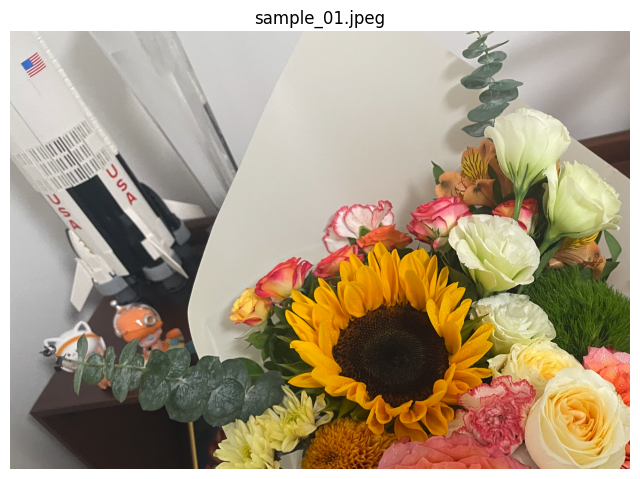

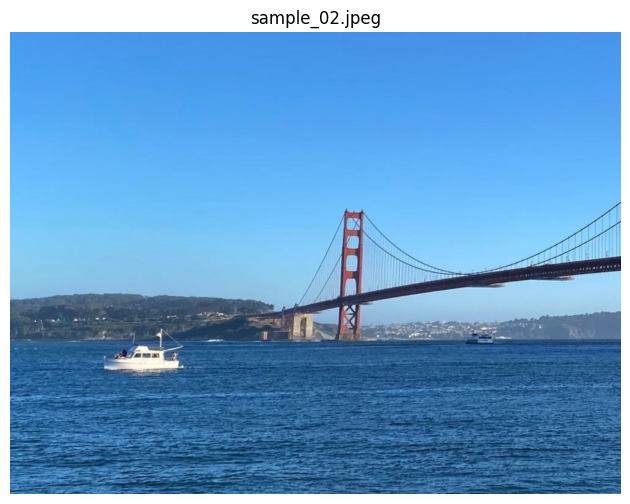

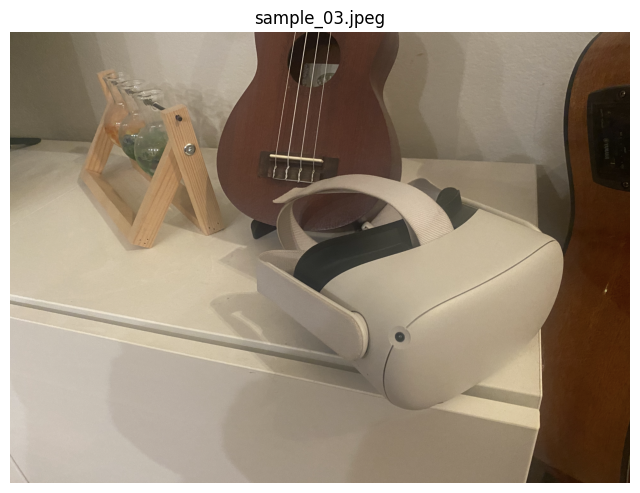

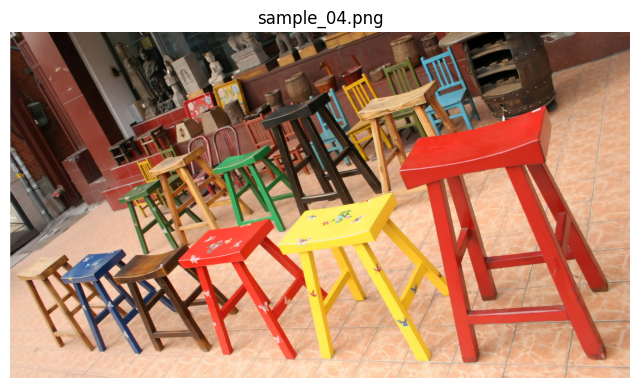

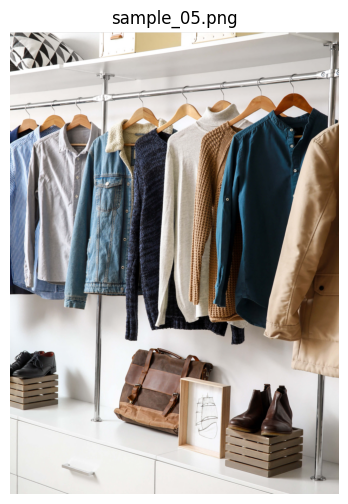

In [7]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

sample_dir = Path("/content/ov-seg/resources/demo_samples")
sample_paths = [
    sample_dir / "sample_01.jpeg",
    sample_dir / "sample_02.jpeg",
    sample_dir / "sample_03.jpeg",
    sample_dir / "sample_04.png",
    sample_dir / "sample_05.png",
]

for path in sample_paths:
    if not path.exists():
        print("missing:", path)
        continue

    img = Image.open(path).convert("RGB")
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.name)
    plt.show()


## 7. 공식 toy examples 일괄 inference

- 출력은 `/content/ov-seg/pred_toy_examples/{example_id}/` 아래에 저장됩니다.
- `sample_01`처럼 같은 이미지에 prompt set이 여러 개인 경우 결과가 덮어써지지 않도록 example별 하위 폴더를 따로 만듭니다.


In [8]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg
mkdir -p pred_toy_examples

python - <<'PY'
from pathlib import Path
import json
import subprocess

repo = Path("/content/ov-seg")
examples = json.loads((repo / "toy_examples.json").read_text(encoding="utf-8"))

ckpt = repo / "checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth"
config = "configs/ovseg_swinB_vitL_demo.yaml"
pred_root = repo / "pred_toy_examples"
sample_dir = repo / "resources/demo_samples"

assert ckpt.exists(), f"checkpoint missing: {ckpt}"

for ex in examples:
    input_path = sample_dir / ex["image"]
    assert input_path.exists(), f"sample image missing: {input_path}"

    out_dir = pred_root / ex["id"]
    out_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 90)
    print("[run]", ex["id"])
    print("image:", input_path)
    print("original proposal_gen:", ex["proposal_gen_original"])
    print("classes:", ", ".join(ex["class_names"]))
    print("output:", out_dir)

    cmd = [
        "python", "demo.py",
        "--config-file", config,
        "--class-names", *ex["class_names"],
        "--input", str(input_path),
        "--output", str(out_dir),
        "--opts", "MODEL.WEIGHTS", str(ckpt),
    ]

    subprocess.run(cmd, cwd=str(repo), check=True)

print("\nAll toy example inference jobs completed.")
PY

find pred_toy_examples -maxdepth 2 -type f -print


[05/05 12:19:20 detectron2]: Arguments: Namespace(class_names=['Saturn V', 'toys', 'desk', 'wall', 'sunflowers', 'white roses', 'chrysanthemums', 'carnations', 'green dianthus'], config_file='configs/ovseg_swinB_vitL_demo.yaml', input=['/content/ov-seg/resources/demo_samples/sample_01.jpeg'], opts=['MODEL.WEIGHTS', '/content/ov-seg/checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth'], output='/content/ov-seg/pred_toy_examples/sample_01_sam_dense_prompts')
WARNING [05/05 12:19:20 fvcore.common.config]: Loading config configs/ovseg_swinB_vitL_demo.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
[05/05 12:19:58 fvcore.common.checkpoint]: [Checkpointer] Loading from /content/ov-seg/checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth ...
[05/05 12:20:15 detectron2]: /content/ov-seg/resources/demo_samples/sample_01.jpeg: finished in 7.58s
[05/05 12:20:21 detectron2]: Arguments: Namespace(class_names=['red bench', 'yellow bench', 'blue bench', 'brown bench',

/content/ov-seg/third_party/CLIP/clip/clip.py:25: UserWarning: PyTorch version 1.7.1 or higher is recommended
  warnings.warn("PyTorch version 1.7.1 or higher is recommended")
/usr/local/miniconda/envs/ovseg/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|███████████████████████████████████████| 933M/933M [00:13<00:00, 70.4MiB/s]
  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/miniconda/envs/ovseg/lib/python3.8/site-packages/detectron2/structures/image_list.py:88: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a

## 8. 결과 시각화

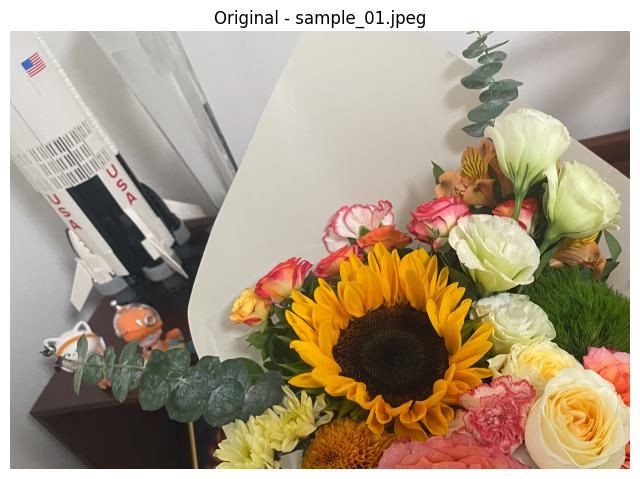

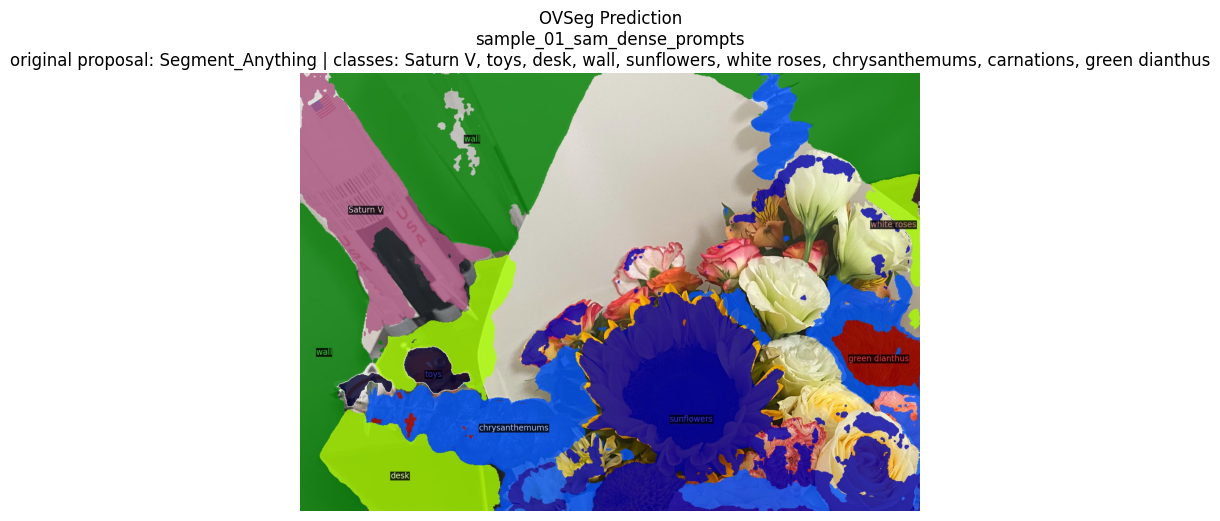

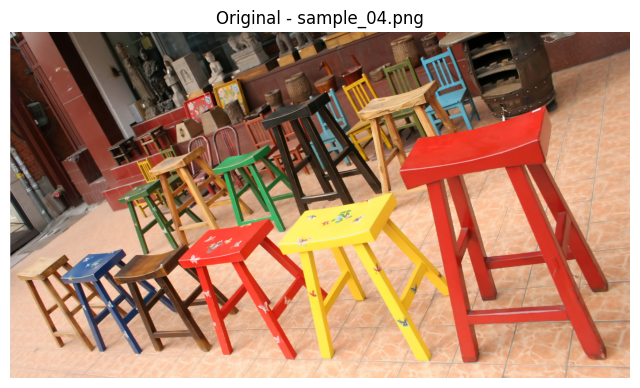

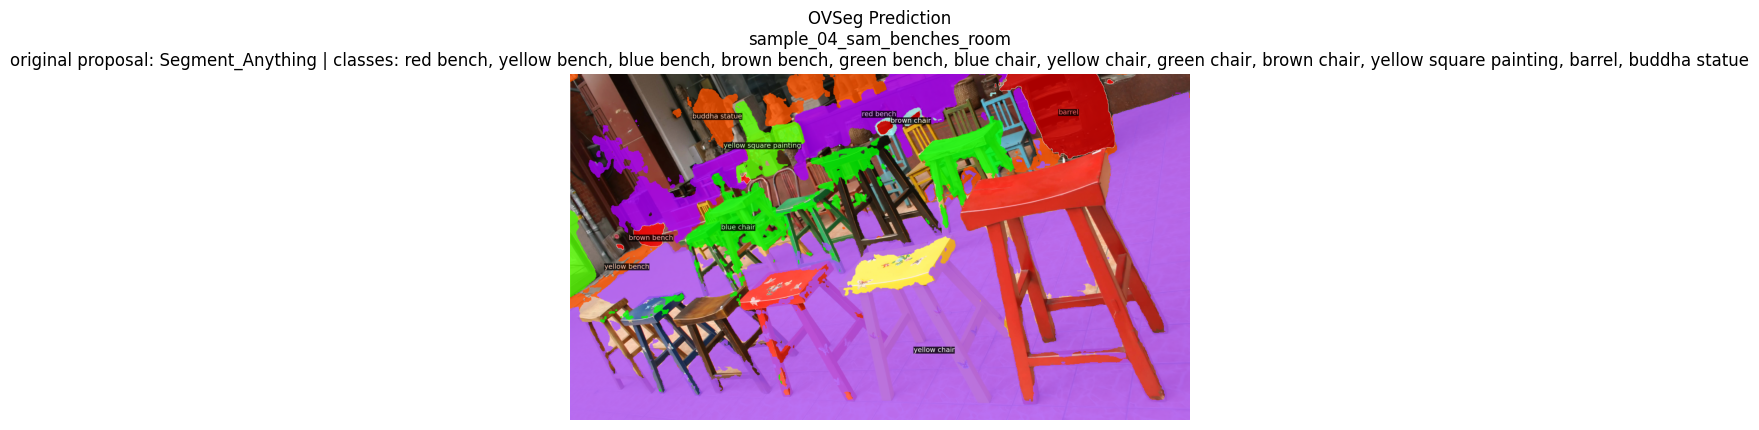

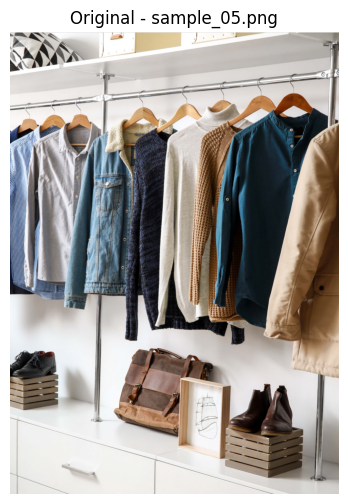

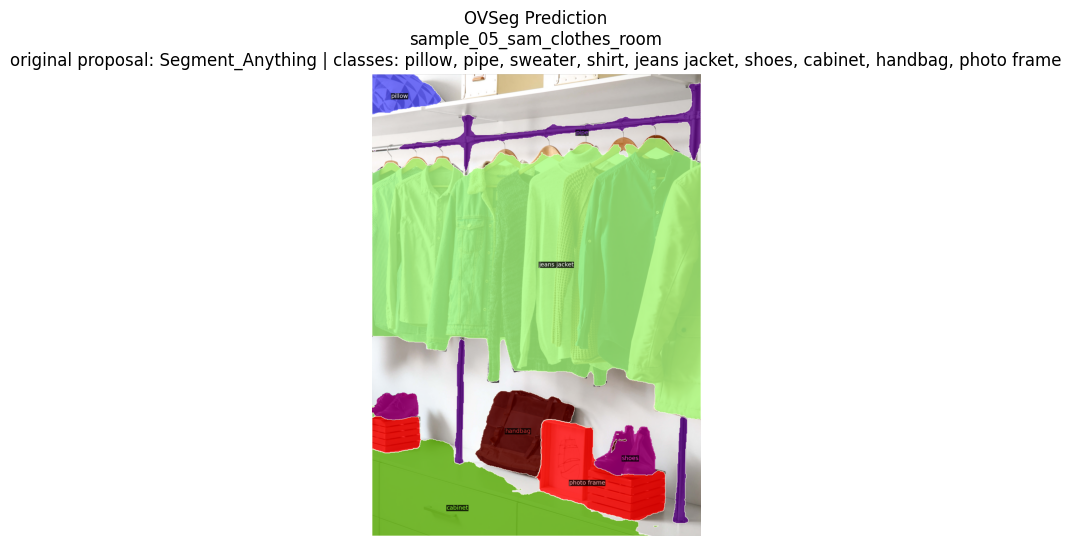

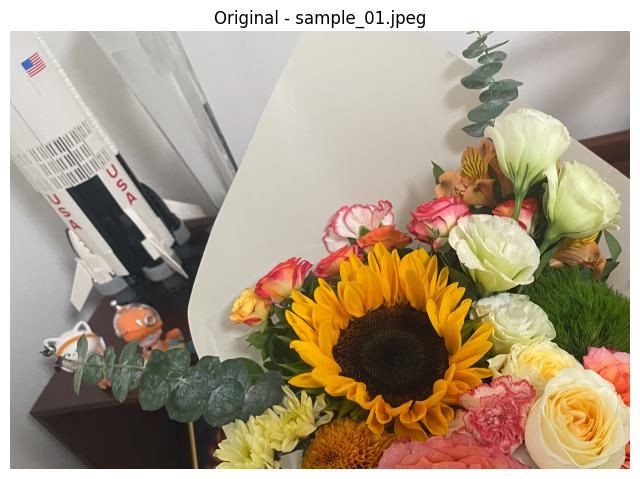

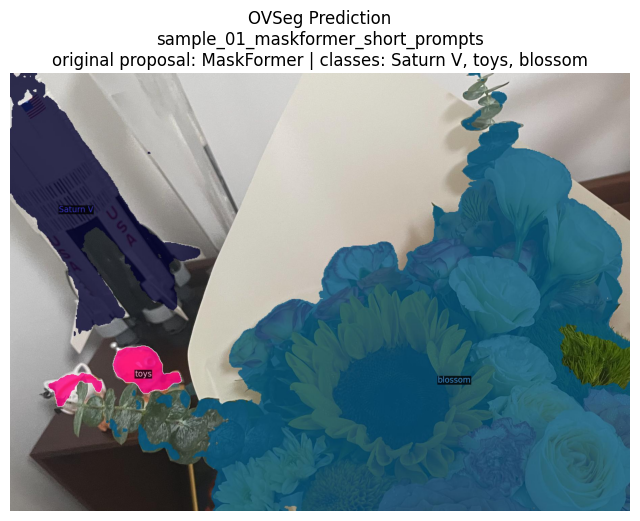

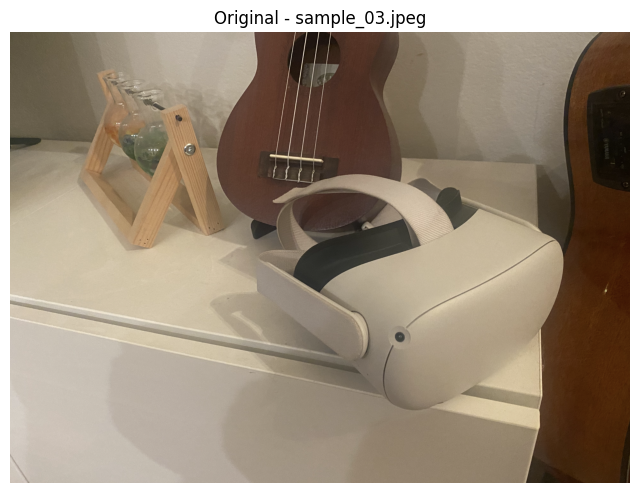

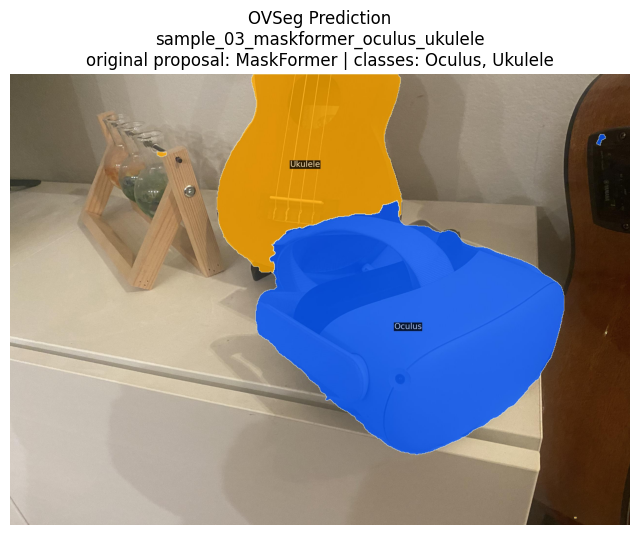

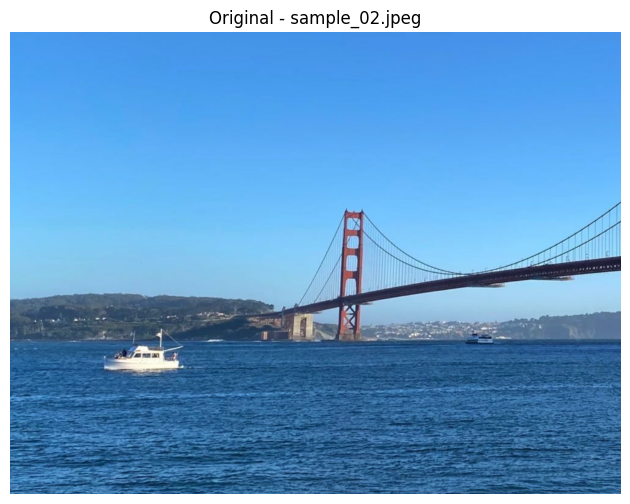

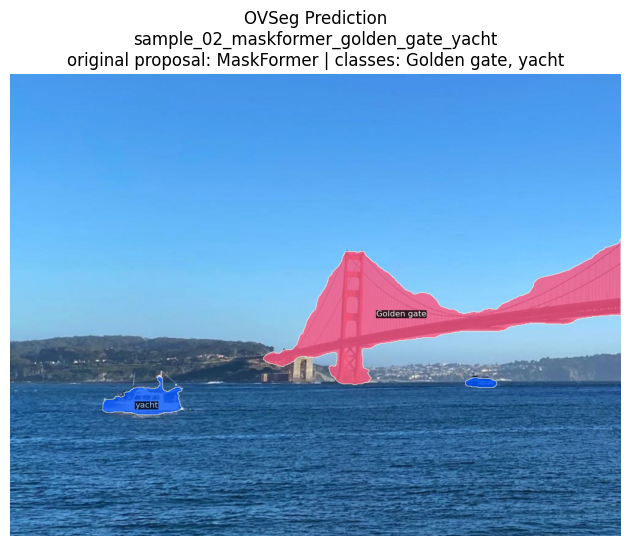

In [9]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json

repo = Path("/content/ov-seg")
examples = json.loads((repo / "toy_examples.json").read_text(encoding="utf-8"))

sample_dir = repo / "resources/demo_samples"
pred_root = repo / "pred_toy_examples"

for ex in examples:
    orig_path = sample_dir / ex["image"]
    pred_path = pred_root / ex["id"] / ex["image"]

    if not orig_path.exists():
        print("missing original:", orig_path)
        continue
    if not pred_path.exists():
        print("missing prediction:", pred_path)
        continue

    orig = Image.open(orig_path).convert("RGB")
    pred = Image.open(pred_path).convert("RGB")

    title = (
        f"{ex['id']}\n"
        f"original proposal: {ex['proposal_gen_original']} | "
        f"classes: {', '.join(ex['class_names'])}"
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(orig)
    plt.axis("off")
    plt.title("Original - " + ex["image"])
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(pred)
    plt.axis("off")
    plt.title("OVSeg Prediction\n" + title)
    plt.show()


## 9. 사용자 이미지로 inference 실행

아래 셀에서 `CUSTOM_IMAGE_PATH`와 `CUSTOM_CLASS_NAMES`만 바꾸면 됩니다.

예시:

```python
CUSTOM_IMAGE_PATH = "/content/my_image.jpg"
CUSTOM_CLASS_NAMES = ["car", "person", "road", "tree"]
```


In [ ]:
%%bash
set -e

source /usr/local/miniconda/etc/profile.d/conda.sh
conda activate ovseg

cd /content/ov-seg

python - <<'PY'
from pathlib import Path
import subprocess

# 여기를 수정해서 사용하세요.
CUSTOM_IMAGE_PATH = Path("/content/ov-seg/resources/demo_samples/sample_02.jpeg")
CUSTOM_CLASS_NAMES = ["Golden gate", "yacht", "water", "sky"]

repo = Path("/content/ov-seg")
ckpt = repo / "checkpoints/ovseg_swinbase_vitL14_ft_mpt.pth"
out_dir = repo / "pred_custom"
out_dir.mkdir(parents=True, exist_ok=True)

assert CUSTOM_IMAGE_PATH.exists(), f"image not found: {CUSTOM_IMAGE_PATH}"
assert ckpt.exists(), f"checkpoint missing: {ckpt}"

cmd = [
    "python", "demo.py",
    "--config-file", "configs/ovseg_swinB_vitL_demo.yaml",
    "--class-names", *CUSTOM_CLASS_NAMES,
    "--input", str(CUSTOM_IMAGE_PATH),
    "--output", str(out_dir),
    "--opts", "MODEL.WEIGHTS", str(ckpt),
]

print("Running custom inference...")
print("image:", CUSTOM_IMAGE_PATH)
print("classes:", ", ".join(CUSTOM_CLASS_NAMES))
subprocess.run(cmd, cwd=str(repo), check=True)
print("saved to:", out_dir)
PY


In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

CUSTOM_IMAGE_PATH = Path("/content/ov-seg/resources/demo_samples/sample_02.jpeg")
pred_path = Path("/content/ov-seg/pred_custom") / CUSTOM_IMAGE_PATH.name

orig = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
pred = Image.open(pred_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(orig)
plt.axis("off")
plt.title("Custom Original")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(pred)
plt.axis("off")
plt.title("Custom OVSeg Prediction")
plt.show()



### CUDA OOM
Colab T4에서 메모리가 부족하면 class prompt 수가 많은 examples에서 실패할 수 있습니다. 먼저 `sample_02`, `sample_03` 같은 짧은 prompt example만 실행해 보고, 필요하면 입력 해상도나 prompt 수를 줄이면 해결 가능합니다.
